## Dependencies

In [1]:
import matplotlib.pyplot as plt
import xgboost as xgb
from tqdm import tqdm
import pandas as pd
import numpy as np 
import joblib

## Functions

In [25]:
# Standard test simulation
def parameters_starter(donor_data: pd.Series, params: dict):
    donation_yield = float(donor_data['Yield'])
    # Find yield dose
    if donation_yield < 5:
        params['yield'] = 0
    elif 5 < donation_yield < 7:
        params['yield'] = 1
    else:
        params['yield'] = 2
    # Find EBV risk bracket
    donor_EBV = float(donor_data['Blood Volume'])
    if 3.8 <= donor_EBV < 4.3:
        params['donorEBVRiskBracket'] = 0
    elif 4.3 <= donor_EBV < 4.8:
        params['donorEBVRiskBracket'] = 1
    else:
        params['donorEBVRiskBracket'] = 2
    params['donorID'] = int(donor_data['Donor ID'])
    params['donorAge'] = int(donor_data['Donor age'])
    params['totalDonations'] = int(donor_data['Donation number'])
    params['donorSex'] = donor_data['Donor sex']
    params['lowerPlateletsCount'] = int(donor_data['Platelets count'])
    params['donationTime'] = int(donor_data['Time'])
    if donor_data['Donation number'] <= 16:
        # Give a chance of having AC reaction history 
        params['donorHasACReactionHistory'] = np.random.choice(['yes', 'no'])
    if donor_data['Donation number'] < 16:
        # Give a chance of having high return history
        params['donorHasHighReturnHistory'] = np.random.choice(['yes', 'no'])
    return params


# Set the chance of the draw and return to be ubnormal depending on what adjustments have been made during the donation
def scenario_orchestrator(params: dict, 
                        bias: bool, 
                        AC_bias: bool, 
                        return_flow_reduced: int, 
                        AC_concentration_reduced: bool, 
                        machine_paused_for_AC: bool):
    # Initaiate output list with normal flow values
    output = ['normal_draw', 'normal_return', 'normal_AC']
    # Calculate chances
    # --- DRAW PHASE
    if bias:
        if params['needleAdjusted'] == 0:
            # 60% chance of being low draw when no needle adjustment is performed
            low_draw = True if np.random.randint(5) in [0, 1, 2] else False
        elif params['needleAdjusted'] == 1:
            # 40% chance of being low draw when needle adjustment is performed
            low_draw = True if np.random.randint(5) in [0, 1] else False
        else:
            # 25% chance of being low draw when 2 needle adjustments are performed
            low_draw = True if np.random.randint(4) == 0 else False
    else:
        if params['needleAdjusted'] == 0:
            # 33% chance of being low draw if no needle adjustment is performed
            low_draw = True if np.random.randint(3) == 0 else False
        elif params['needleAdjusted'] == 1:
            # 20% chance of being low draw when needle adjustment is performed
            low_draw = True if np.random.randint(5) == 0 else False
        else:
            # 10% chance of being low draw if needle adjustment is performed
            low_draw = True if np.random.randint(10) == 0 else False
    # --- RETURN PHASE
    # Determine baseline risk using the "reduce return speed" label rules
    total_donations = params['totalDonations']
    operator = params['operator']
    vein_used = params['veinUsed']
    history = params['donorHasHighReturnHistory']
    instances = params['highReturnInstances']
    # Risk flag
    is_high_risk = False
    # Flag high risk based on the label rules 
    if total_donations >= 70:
        is_high_risk = True
    elif 15 < total_donations < 70 and (operator == 'junior' and vein_used == 'Basilic'):
        is_high_risk = True
    elif total_donations < 16 and (history == 'yes' or operator == 'junior' or vein_used == 'Basilic'):
        is_high_risk = True
    elif total_donations >= 70 and (operator == 'junior' or vein_used == 'Basilic'):
        is_high_risk = True
    if is_high_risk:
        # 33% starting chance of being high return if risk factors are present (moderately mitigated)
        high_return = True if np.random.randint(3 + return_flow_reduced) == 0 else False
    else:
        # 16.6% starting chance of being high return (moderately mitigated)
        high_return = True if np.random.randint(6 + return_flow_reduced) == 0 else False
    # --- AC PHASE
    if AC_bias:
        # High risk donors chances
        if params['donorEBVRiskBracket'] == 0:
            if machine_paused_for_AC:
                # 50% chance of being high AC
                high_AC = True if np.random.randint(2) == 0 else False
            elif AC_concentration_reduced:
                # 40% chance of being high AC
                high_AC = True if np.random.randint(5) in [0, 1] else False
            elif AC_concentration_reduced and machine_paused_for_AC:
                # 33% chance of being high AC
                high_AC = True if np.random.randint(3) == 0 else False
            else:
                # 60% chance of being high AC
                high_AC = True if np.random.randint(5) in [0, 1, 2] else False
        # Medium risk donors chances
        elif params['donorEBVRiskBracket'] == 1:
            if machine_paused_for_AC:
                # 40% chance of being high AC
                high_AC = True if np.random.randint(5) in [0, 1] else False
            elif AC_concentration_reduced:
                # 33% chance of being high AC
                high_AC = True if np.random.randint(3) == 0 else False
            elif AC_concentration_reduced and machine_paused_for_AC:
                # 20% chance of being high AC
                high_AC = True if np.random.randint(5) == 0 else False
            else:
                # 50% chance of being high AC
                high_AC = True if np.random.randint(2) == 0 else False
        # Low risk donors chances
        elif params['donorEBVRiskBracket'] == 2:
            if machine_paused_for_AC:
                # 33% chance of being high AC
                high_AC = True if np.random.randint(3) == 0 else False
            elif AC_concentration_reduced:
                # 20% chance of being high AC
                high_AC = True if np.random.randint(5) == 0 else False
            elif AC_concentration_reduced and machine_paused_for_AC:
                # 10% chance of being high AC
                high_AC = True if np.random.randint(10) == 0 else False
            else:
                # 40% chance of being high AC
                high_AC = True if np.random.randint(5) in [0, 1] else False
    else:
        # High risk donors chances
        if params['donorEBVRiskBracket'] == 0:
            if AC_concentration_reduced and machine_paused_for_AC:
                # 10% chance of being high AC
                high_AC = True if np.random.randint(10) == 0 else False
            elif AC_concentration_reduced:
                # 20% chance of being high AC
                high_AC = True if np.random.randint(5) == 0 else False
            elif machine_paused_for_AC:
                # 33% chance of being high AC
                high_AC = True if np.random.randint(3) == 0 else False
            else:
                # 40% chance of being high AC
                high_AC = True if np.random.randint(5) in [0, 1] else False
        # Medium and Low risk donors chances
        else:
            if AC_concentration_reduced and machine_paused_for_AC:
                # 3% chance of being high AC
                high_AC = True if np.random.randint(33) == 0 else False
            elif AC_concentration_reduced:
                # 10% chance of being high AC
                high_AC = True if np.random.randint(10) == 0 else False
            elif machine_paused_for_AC:
                # 16.6% chance of being high AC
                high_AC = True if np.random.randint(6) == 0 else False
            else:
                # 20% chance of being high AC
                high_AC = True if np.random.randint(5) == 0 else False
    # Assign output
    if low_draw:
        output[0] = 'low_draw'
    if high_return:
        output[1] = 'high_return'
    if high_AC:
        output[-1] = 'high_AC'
    return output


def low_draw_stop_logic(params: dict):
    # Only stop machine in case of 3 red squares in a row
    if params['prev_variance'] == 0 and params['prev_variance_1'] == 0 and params['machineRedSquaresVarianceInCicles'] == 0:
        params['instancesMachineStopped'] += 1
        # Extend donation due to low draw speed
        params['donationTime'] += 10
        return params
    else: return params


def draw_speed_boost(params: dict, initial_donation_time: int):
    cycle_variance = params['machineRedSquaresVarianceInCicles']
    current_donation_time = params['donationTime']
    # Speed up donation ONLY if the last 5 cycles were good, and the donation time is currently longer than the original predictet time
    if cycle_variance > 4 and current_donation_time > initial_donation_time:
        if (current_donation_time - params['donationElapsedTime']) <= 11:
            pass
        else:
            params['donationTime'] -= 10
    return params


def prev_variance_updater(params: dict):
    params['prev_variance_1'] = params['prev_variance']
    params['prev_variance'] = params['machineRedSquaresVarianceInCicles']
    return params


def draw_flow(orchestrator_output: list, params: dict, original_time: int):
    # Check orchestrator output
    if 'low_draw' == orchestrator_output[0]:
        # Add probability of the machine stopping due to low draw, variance <= 2, machine paused >=3
        params = prev_variance_updater(params)
        params['machineRedSquaresVarianceInCicles'] = 0
        params = low_draw_stop_logic(params)
    else:
        params = prev_variance_updater(params)
        params['machineRedSquaresVarianceInCicles'] = int(params['machineRedSquaresVarianceInCicles']) + 1
        params = draw_speed_boost(params, original_time)
    return params


def return_flow(orchestrator_output: list, params: dict):
    end_donation = False
    # Check orchestrator output
    if 'high_return' in orchestrator_output:
        # 7% chance that the return bruises the donor
        if (np.random.randint(14) == 0):
            params['timePressureBarGoingToYellowInSeconds'] = np.random.randint(6, 11)
            params['highReturnInstances'] += 1
            end_donation = True
            return params, end_donation
        # 50% chance of being a slightly high return flow
        if (np.random.randint(2) == 0):
            params['timePressureBarGoingToYellowInSeconds'] = np.random.randint(3, 6)
        else:
            params['timePressureBarGoingToYellowInSeconds'] = np.random.randint(6, 11)
            params['highReturnInstances'] += 1
    # If not high return, reset the seconds count
    else:
        params['timePressureBarGoingToYellowInSeconds'] = 0
    return params, end_donation


def AC_flow(orchestrator_output: list, params: dict):
    # Check for previous cycle reaction
    if params['reactionSeverity'] != 0:
        # Update previous reaction parameter
        params['prevACReaction'] = params['reactionSeverity']
    params['reactionSeverity'] = 0
    # Check orchestrator output
    if 'high_AC' in orchestrator_output:
        # 33% chance of AC reaction symptoms
        if (np.random.randint(3) == 0):
            params['reactionSeverity'] = int(np.random.choice([1, 2, 3], p=[0.7, 0.2, 0.1]))
            params['donorCurrentDonationReaction'] += 1
            params['instancesMachineWasStoppedByOperator'] += 1
    return params


def assign_label(params: dict, eval: str = 'off'):
    detected_priorities = []
    # --- PRIORITY 1: Stop Donation ---
    if (params['reactionSeverity'] == 3 or
        (params['donorCurrentDonationReaction'] == 3) or
        # 1st reaction
            # High EBV risk bracket
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 2) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 1 and params['yield'] > 0) or
        # 2nd reaction
            # High EBV risk bracket
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'yes' and params['prevACReaction'] == 1 and params['yield'] == 0 and params['reactionSeverity'] != 0) or
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'no' and params['prevACReaction'] == 2 and params['reactionSeverity'] != 0) or
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'no' and params['prevACReaction'] == 1 and params['yield'] > 0 and params['reactionSeverity'] != 0) or
            # Medium EBV risk bracket
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'yes' and params['prevACReaction'] == 2 and params['reactionSeverity'] != 0) or
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'yes' and params['prevACReaction'] == 1 and params['yield'] == 2 and params['reactionSeverity'] != 0) or
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'no' and params['prevACReaction'] == 2 and params['yield'] == 2 and params['reactionSeverity'] != 0) or
            # Low EBV risk bracket
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 2 and params['donorHasACReactionHistory'] == 'yes' and params['prevACReaction'] == 2 and params['yield'] == 2 and params['reactionSeverity'] != 0)):
            detected_priorities.append((1, 'End donation, AC toxicity reached/buildup'))

    # --- PRIORITY 2: Reduce AC ---
        # 1st reaction
            # High EBV risk bracket
    if ((params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 1 and params['yield'] == 0) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'no' and params['reactionSeverity'] == 2) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'no' and params['reactionSeverity'] == 1 and params['yield'] > 0) or
            # Medium EBV risk bracket
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 2) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 1 and params['yield'] == 2) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'no' and params['reactionSeverity'] == 2 and params['yield'] == 2) or
            # Low EBV risk bracket
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 2 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 2 and params['yield'] == 2) or
        # 2nd reaction
            # High EBV risk bracket
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 0 and params['donorHasACReactionHistory'] == 'no' and params['prevACReaction'] == 1 and params['yield'] == 0 and params['reactionSeverity'] != 0) or
            # Medium EBV risk bracket
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'yes' and params['prevACReaction'] == 1 and params['yield'] < 2 and params['reactionSeverity'] != 0) or
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'no' and params['prevACReaction'] == 2 and params['yield'] < 2 and params['reactionSeverity'] != 0) or
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'no' and params['prevACReaction'] == 1 and params['reactionSeverity'] != 0) or
            # Low EBV risk bracket
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 2 and params['donorHasACReactionHistory'] == 'yes' and params['prevACReaction'] == 2 and params['yield'] < 2 and params['reactionSeverity'] != 0) or
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 2 and params['donorHasACReactionHistory'] == 'yes' and params['prevACReaction'] == 1 and params['reactionSeverity'] != 0) or
        (params['donorCurrentDonationReaction'] == 2 and params['donorEBVRiskBracket'] == 2 and params['donorHasACReactionHistory'] == 'no' and params['prevACReaction'] != 0 and params['reactionSeverity'] != 0)):
        detected_priorities.append((2, 'Inform nurse and lower AC concentration'))

    # --- PRIORITY 3: Pause Machine ---
        # 1st reaction
            # Medium EBV risk bracket
    if ((params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 1 and params['yield'] < 2) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'no' and params['reactionSeverity'] == 2 and params['yield'] < 2) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 1 and params['donorHasACReactionHistory'] == 'no' and params['reactionSeverity'] == 1) or
            # Low EBV risk bracket
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 2 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 2 and params['yield'] < 2) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 2 and params['donorHasACReactionHistory'] == 'yes' and params['reactionSeverity'] == 1) or
        (params['donorCurrentDonationReaction'] == 1 and params['donorEBVRiskBracket'] == 2 and params['donorHasACReactionHistory'] == 'no' and params['reactionSeverity'] != 0)):
        detected_priorities.append((3, 'Pause machine for 1 minute and inform nurse'))

    # --- PRIORITY 4: Return Speed --- /// --- rules have been update to consider vein scarring
    if ((params['timePressureBarGoingToYellowInSeconds'] >= 6 and params['operator'] == 'junior' and 15 < params['totalDonations'] < 70) or
        (params['timePressureBarGoingToYellowInSeconds'] >= 6 and params['veinUsed'] == 'Basilic' and 15 < params['totalDonations'] < 70) or
        (params['timePressureBarGoingToYellowInSeconds'] >= 6 and params['totalDonations'] >= 70) or
        (params['timePressureBarGoingToYellowInSeconds'] >= 6 and params['highReturnInstances'] % 2 == 0 and 15 < params['totalDonations'] < 70) or
        (params['timePressureBarGoingToYellowInSeconds'] >= 6 and params['totalDonations'] < 16 and params['donorHasHighReturnHistory'] == 'yes') or 
        (params['timePressureBarGoingToYellowInSeconds'] >= 6 and params['totalDonations'] < 16 and params['operator'] == 'junior') or 
        (params['timePressureBarGoingToYellowInSeconds'] >= 6 and params['totalDonations'] < 16 and params['veinUsed'] == 'Basilic')):
        detected_priorities.append((4, 'Lower return speed from terminal'))
    # --- PRIORITY 5: Needle Adjustment 1 ---
    if eval == 'on':
        if (params['needleAdjusted'] == 0 and \
            params['prev_variance'] == 0 and params['machineRedSquaresVarianceInCicles'] == 0):
            detected_priorities.append((5, 'Request first needle adjustment'))
    else:
        if (params['dummyNeedleAdjusted'] == 0 and \
            params['prev_variance'] == 0 and params['machineRedSquaresVarianceInCicles'] == 0):
            detected_priorities.append((5, 'Request first needle adjustment'))
    # --- PRIORITY 6: Needle Adjustment 2 ---
    if eval == 'on':
        if (params['needleAdjusted'] == 1 and \
            params['prev_variance'] == 0 and params['machineRedSquaresVarianceInCicles'] == 0):
            detected_priorities.append((6, 'Request second needle adjustment'))
    else:
        if (params['dummyNeedleAdjusted'] == 1 and \
            params['prev_variance'] == 0 and params['machineRedSquaresVarianceInCicles'] == 0):
            detected_priorities.append((6, 'Request second needle adjustment'))
    # Final Decision: Sort by priority (lowest number first) and pick the top one
    if detected_priorities:
        detected_priorities.sort(key=lambda x: x[0])
        params['label'] = detected_priorities[0][1]
    else:
        params['label'] = 'No action'
    return params


def running_sim(donor_data: pd.Series, outcomes: dict):
    # Initiate parameters
    params = {
        'donorID': 0,
        'donorAge': 0,                                                                                
        'reactionSeverity': 0,                       
        'donorCurrentDonationReaction': 0,                                           
        'timePressureBarGoingToYellowInSeconds': 0,                                 
        'instancesMachineWasStoppedByOperator': 0,                                   
        'instancesMachineStopped': 0,  
        'lowerPlateletsCount': 0,                                                    
        'donationElapsedTime': 5,                                               
        'donorSex': '',                                                               
        'dummyNeedleAdjusted': 0,                                
        'needleAdjusted': 0,                        
        'donorHasLowDrawHistory': 'no',                                      
        'donorHasHighReturnHistory': 'no',                
        'donorEBVRiskBracket': 0,                            
        'prev_variance': 2,
        'prev_variance_1': 1,
        'machineRedSquaresVarianceInCicles': 3,                                  
        'donationTime': 0,
        'donorHasACReactionHistory': 'no',
        'prevACReaction': 0,
        'yield': 0,                                      
        'operator': '',
        'veinUsed': '',
        'highReturnInstances': 0,
        'totalDonations': 0,
        'label': 'No action',
    }
    # Update parameters to current donor
    params = parameters_starter(donor_data, params)
    # Assign random operator type
    params['operator'] = np.random.choice(['junior', 'senior'])
    # Assign random vein used
    params['veinUsed'] = np.random.choice(['Cephalic', 'Basilic', 'Median'], p=[0.2, 0.3, 0.5])
    # Extract donation time from list
    donation_time = int(donor_data['Time'])
    # Draw bias, 50% chance of biased draw
    bias = True if (np.random.randint(2) == 0) else False
    # AC bias, 50% chance of biased AC for female donor
    AC_bias = True if (np.random.randint(2) == 0) else False
    # --- FLAGS SETUP ---
    # Return flow reduced flag
    reduced_return = 0
    # AC reduction flag
    reduced_AC = False
    # Machine pause due to AC reaction flag
    machine_paused_for_AC = False
    # Extract donor ID
    donor_ID = int(donor_data['Donor ID'])
    # Initiate donation outcome
    outcome = 'No issues'
    # Initiate donation status
    end_donation_status = False
    # Initial donation time
    initial_time = params['donationTime']
    # Loop through the minutes, and perform 1 return and 1 draw each minute
    for loop in range(donation_time - 5):
        # Initiate dataframe to store each loop data
        scenario = scenario_orchestrator(params, bias, AC_bias, reduced_return, reduced_AC, machine_paused_for_AC)
        params = AC_flow(scenario, params)
        params = draw_flow(scenario, params, initial_time)
        params, end_donation_status = return_flow(scenario, params)
        params = assign_label(params)
        if end_donation_status:
            outcome = 'Donation stopped due to high return'
        if 'End donation,' in params['label']:
            end_donation_status = True
            outcome = 'Donation stopped due to AC reaction/buildup'
        # Dataset setup
        if loop == 0:
            anchor = pd.DataFrame(params, index=[0])
        else:
            # Generate a new pandas series to add to the main dataframe
            new_entry = pd.DataFrame(params, index=[0])
            # Add overwritten params to the dataframe
            anchor = pd.concat([anchor, new_entry], axis=0)
            # Stop donation if it slows down to be longer than 94 minutes
            if params['donationTime'] > 94:
                end_donation_status = True
                outcome = 'Donation stopped due to timeout'
        # Check for needle adjustments
        if params['label'] == 'Request first needle adjustment' or \
        params['label'] == 'Request second needle adjustment':
            params['dummyNeedleAdjusted'] += 1
        # Check early stop flag
        if end_donation_status:
            break
        params['donationElapsedTime'] += 1
    # If donation stopped early, return simulation results
    if end_donation_status:
        pass
    # If donation completed normally, check for time extension
    else:
        # Check for time dilation due to low draw
        new_donation_time = params['donationTime']
        # Set up stack for while loop
        extended_time_history = [new_donation_time]
        force_stop_donation = False
        original_time_history = [donation_time]
        if donation_time != new_donation_time:
            while original_time_history[-1] != extended_time_history[-1]:
                # Keep looping through the minutes, and perform 1 return and 1 draw each minute
                for loop in range(new_donation_time - donation_time):
                    # Ensure donation does not keep going after time update (speed boost)
                    if params['donationElapsedTime'] == params['donationTime']:
                        # Break for and while loop
                        force_stop_donation = True
                        break
                    scenario = scenario_orchestrator(params, bias, AC_bias, reduced_return, reduced_AC, machine_paused_for_AC)
                    params = AC_flow(scenario, params)
                    params = draw_flow(scenario, params, initial_time)
                    params, end_donation_status = return_flow(scenario, params)
                    params = assign_label(params)
                    if end_donation_status:
                        outcome = 'Donation stopped due to high return'
                    if 'End donation,' in params['label']:
                        end_donation_status = True
                        outcome = 'Donation stopped due to AC reaction/buildup'
                    # Generate a new pandas series to add to the main dataframe
                    new_entry = pd.DataFrame(params, index=[0])
                    # Add overwritten params to the dataframe
                    anchor = pd.concat([anchor, new_entry], axis=0)
                    # Stop donation if it slows down to be longer than 94 minutes
                    if params['donationTime'] > 94:
                        end_donation_status = True
                        outcome = 'Donation stopped due to timeout'
                    # End donation early
                    if end_donation_status:
                        force_stop_donation = True
                        break
                    params['donationElapsedTime'] += 1
                if force_stop_donation:
                    break
                original_time_history.append(extended_time_history[-1])
                extended_time_history.append(params['donationTime'])
    outcomes['donor_ID'].append(donor_ID)
    outcomes['AC_bias'].append(AC_bias)
    outcomes['Draw_bias'].append(bias)
    outcomes['Num_return_reduced'].append(reduced_return)
    outcomes['outcome'].append(outcome)
    return anchor, outcomes


def test_sim_engine(dataset_path: str = None, dataset: pd.DataFrame = None):
    # Read the source data
    if not dataset_path:
        entire_data = dataset
    else:
        entire_data = pd.read_csv(dataset_path)
    # Donation outcomes
    outcomes = {
        'donor_ID': [],
        'AC_bias': [],
        'Draw_bias': [],
        'Num_return_reduced': [],
        'outcome': []
    }
    # Loop through the dataset rows
    for idx in tqdm(range(len(entire_data))):
        if idx == 0:
            seed_df, outcomes = running_sim(entire_data.loc[idx], outcomes)
        else:
            latest_entry, outcomes = running_sim(entire_data.loc[idx], outcomes)
            seed_df = pd.concat([seed_df, latest_entry], axis=0)
    pd_outcomes = pd.DataFrame(outcomes)
    return seed_df, pd_outcomes


In [20]:
# XGB-assisted simulation
class XGBInferenceWrapper:
    def __init__(self, model, le_dict, target_encoder):
        self.model = model
        self.le_dict = le_dict 
        self.target_encoder = target_encoder
        self.feature_names = [
            'donorAge', 'reactionSeverity', 'donorCurrentDonationReaction', 
            'timePressureBarGoingToYellowInSeconds', 'instancesMachineWasStoppedByOperator', 
            'instancesMachineStopped', 'lowerPlateletsCount', 'donationElapsedTime', 
            'donorSex', 'needleAdjusted', 'donorHasLowDrawHistory', 
            'donorHasHighReturnHistory', 'donorEBVRiskBracket', 'prev_variance', 
            'prev_variance_1', 'machineRedSquaresVarianceInCicles', 'donationTime', 
            'donorHasACReactionHistory', 'prevACReaction', 'yield', 'operator', 
            'veinUsed', 'highReturnInstances', 'totalDonations'
        ]
    def predict(self, params_dict):
        # Convert to DataFrame and LOCK the column order
        df = pd.DataFrame([params_dict])
        # Ensure only training features are present and in the right order
        df = df[self.feature_names].copy()
        # Encode categorical columns
        for col, encoder in self.le_dict.items():
            if col in df.columns:
                # Force to string to match '.astype(str)' used in training
                val_as_str = str(df.iloc[0][col]) 
                try:
                    df[col] = encoder.transform([val_as_str])[0]
                except ValueError:
                    # Fallback for unseen labels: use the first known class
                    df[col] = 0 
        # Final Type Cast
        df = df.astype('float32')
        # XGBoost Prediction
        dmat = xgb.DMatrix(df, feature_names=self.feature_names)
        probs = self.model.predict(dmat)
        # Handle Softprob Output
        class_index = np.argmax(probs, axis=1)
        return self.target_encoder.inverse_transform(class_index)


inference_engine = joblib.load('inference_pipeline_mk3.pkl')


def xgb_inference(params: dict):  
    result = inference_engine.predict(params)
    params['predLabel'] = result[0]
    return params


def prev_variance_updater(params: dict):
    params['prev_variance_1'] = params['prev_variance']
    params['prev_variance'] = params['machineRedSquaresVarianceInCicles']
    return params  


def MMO_eval_running_sim(donor_data: pd.Series, outcomes: dict):
    # Initiate parameters
    params = {
        'donorID': 0,
        'donorAge': 0,                                                                         
        'reactionSeverity': 0,                  
        'donorCurrentDonationReaction': 0,                                          
        'timePressureBarGoingToYellowInSeconds': 0,                                 
        'instancesMachineWasStoppedByOperator': 0,                                
        'instancesMachineStopped': 0,  
        'lowerPlateletsCount': 0,                                                  
        'donationElapsedTime': 5,                                                
        'donorSex': '',                                               
        'needleAdjusted': 0,                                               
        'donorHasLowDrawHistory': 'no',                                          
        'donorHasHighReturnHistory': 'no',                 
        'donorEBVRiskBracket': 0,                       
        'prev_variance': 2,
        'prev_variance_1': 1,
        'machineRedSquaresVarianceInCicles': 3,                                     
        'donationTime': 0,
        'donorHasACReactionHistory': 'no',
        'prevACReaction': 0,
        'yield': 0,                                        
        'operator': '',
        'veinUsed': '',
        'highReturnInstances': 0,
        'totalDonations': 0,
        'label': 'No action',
        'predLabel': 'No action'
    }
    # Update parameters to current donor
    params = parameters_starter(donor_data, params)
    # Assign random operator type
    params['operator'] = np.random.choice(['junior', 'senior'])
    # Assign random vein used
    params['veinUsed'] = np.random.choice(['Cephalic', 'Basilic', 'Median'], p=[0.2, 0.3, 0.5])
    # Extract donation time from list
    donation_time = int(donor_data['Time'])
    # Draw bias, 50% chance of biased draw
    bias = True if (np.random.randint(2) == 0) else False
    # AC bias, 50% chance of biased AC for male donor
    AC_bias = True if (np.random.randint(2) == 0) else False
    # Return flow reduced flag
    reduced_return = 0
    # AC reduction flag
    reduced_AC = False
    # Machine pause due to AC reaction flag
    machine_paused_for_AC = False
    # Extract donor ID
    donor_ID = int(donor_data['Donor ID'])
    # Initiate donation outcome
    outcome = 'No issues'
    # Initiate donation status
    end_donation_status = False
    # Initial donation time
    initial_time = params['donationTime']
    # Loop through the minutes, and perform 1 return and 1 draw each minute
    for loop in range(donation_time - 5):
        scenario = scenario_orchestrator(params, bias, AC_bias, reduced_return, reduced_AC, machine_paused_for_AC)
        params = AC_flow(scenario, params)
        params = draw_flow(scenario, params, initial_time)
        params, end_donation_status = return_flow(scenario, params)
        params = assign_label(params, eval='on')
        params = xgb_inference(params)
        # Check for return flow reduction
        if params['predLabel'] == 'Lower return speed from terminal':
            reduced_return += 1
            params['donationTime'] += 3
        # Check for AC concentration reduction
        if params['predLabel'] == 'Inform nurse and lower AC concentration':
            reduced_AC = True
        # Check for machine pause due to AC reaction
        if params['predLabel'] == 'Pause machine for 1 minute and inform nurse':
            machine_paused_for_AC = True
        # Check for donation early stop due to haematoma
        if end_donation_status:
            outcome = 'Donation stopped due to high return'
        # Check for donation early stop due to Ac reaction
        if 'End donation,' in params['label']:
            end_donation_status = True
            outcome = 'Donation stopped due to AC reaction/buildup'
        # Initiate dataframe to store each loop data
        if loop == 0:
            anchor = pd.DataFrame(params, index=[0])
        else:
            # Generate a new pandas series to add to the main dataframe
            new_entry = pd.DataFrame(params, index=[0])
            # Add overwritten params to the dataframe
            anchor = pd.concat([anchor, new_entry], axis=0)
            # Stop donation if it slows down to be longer than 94 minutes
            if params['donationTime'] > 94:
                end_donation_status = True
                outcome = 'Donation stopped due to timeout'
        # Check for needle adjustments
        if params['predLabel'] == 'Request first needle adjustment' or \
        params['predLabel'] == 'Request second needle adjustment':
            params['needleAdjusted'] += 1
        if end_donation_status:
            break
        # Add to donation time tracker
        params['donationElapsedTime'] += 1
    # If donation stopped early, return simulation results
    if end_donation_status:
        pass
    # If donation completed normally, check for time extension
    else:
        # Check for time dilation due to low draw
        new_donation_time = params['donationTime']
        # Set up stack for while loop
        extended_time_history = [new_donation_time]
        force_stop_donation = False
        original_time_history = [donation_time]
        if donation_time != new_donation_time:
            while original_time_history[-1] != extended_time_history[-1]:
                # Keep looping through the minutes, and perform 1 return and 1 draw each minute
                for loop in range(new_donation_time - donation_time):
                    # Ensure donation does not keep going after time update (speed boost)
                    if params['donationElapsedTime'] == params['donationTime']:
                        # Break for and while loop
                        force_stop_donation = True
                        break
                    scenario = scenario_orchestrator(params, bias, AC_bias, reduced_return, reduced_AC, machine_paused_for_AC)
                    params = AC_flow(scenario, params)
                    params = draw_flow(scenario, params, initial_time)
                    params, end_donation_status = return_flow(scenario, params)
                    params = assign_label(params, eval='on')
                    params = xgb_inference(params)
                    # Check for return flow reduction
                    if params['predLabel'] == 'Lower return speed from terminal':
                        reduced_return += 1
                        params['donationTime'] += 3
                    # Check for AC concentration reduction
                    if params['predLabel'] == 'Inform nurse and lower AC concentration':
                        reduced_AC = True
                    # Check for machine pause due to AC reaction
                    if params['predLabel'] == 'Pause machine for 1 minute and inform nurse':
                        machine_paused_for_AC = True
                    if end_donation_status:
                        outcome = 'Donation stopped due to high return'
                    if 'End donation,' in params['label']:
                        end_donation_status = True
                        outcome = 'Donation stopped due to AC reaction/buildup'
                    # Generate a new pandas series to add to the main dataframe
                    new_entry = pd.DataFrame(params, index=[0])
                    # Add overwritten params to the dataframe
                    anchor = pd.concat([anchor, new_entry], axis=0)
                    # Stop donation if it slows down to be longer than 94 minutes
                    if params['donationTime'] > 94:
                        end_donation_status = True
                        outcome = 'Donation stopped due to timeout'
                    # Check for needle adjustments
                    if params['predLabel'] == 'Request first needle adjustment' or \
                    params['predLabel'] == 'Request second needle adjustment':
                        params['needleAdjusted'] += 1
                    # End donation early
                    if end_donation_status:
                        force_stop_donation = True
                        break
                    params['donationElapsedTime'] += 1
                if force_stop_donation:
                    break
                original_time_history.append(extended_time_history[-1])
                extended_time_history.append(params['donationTime'])
    outcomes['donor_ID'].append(donor_ID)
    outcomes['AC_bias'].append(AC_bias)
    outcomes['Draw_bias'].append(bias)
    outcomes['Num_return_reduced'].append(reduced_return)
    outcomes['outcome'].append(outcome)
    return anchor, outcomes


def eval_sim_engine(dataset_path: str = None, dataset: pd.DataFrame = None):
    # Read the source data
    if not dataset_path:
        entire_data = dataset
    else:
        entire_data = pd.read_csv(dataset_path)
    # Donation outcomes
    outcomes = {
        'donor_ID': [],
        'AC_bias': [],
        'Draw_bias': [],
        'Num_return_reduced': [],
        'outcome': []
    }
    # Loop through the dataset rows
    for idx in tqdm(range(len(entire_data))):
        if idx == 0:
            seed_df, outcomes = MMO_eval_running_sim(entire_data.loc[idx], outcomes)
        else:
            latest_entry, outcomes = MMO_eval_running_sim(entire_data.loc[idx], outcomes)
            seed_df = pd.concat([seed_df, latest_entry], axis=0)
    pd_outcomes = pd.DataFrame(outcomes)
    return seed_df, pd_outcomes


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:
def calculate_nadler_bv(sex: str, height_cm: float, weight_kg: float):
    h_m = height_cm / 100
    if sex == 'M':
        bv = (0.3669 * (h_m**3)) + (0.03219 * weight_kg) + 0.6041
    else:
        bv = (0.3561 * (h_m**3)) + (0.03308 * weight_kg) + 0.1833
    return bv


def predict_platelet_yield(sex: str, 
                            weight_kg: float, 
                            height_cm: float, 
                            hematocrit: float, 
                            platelet_count_k_per_ul: int):
    # Simulation Constants
    TARGET_YIELDS_E11 = [8.2, 7.8, 5.8, 5.4, 5.1, 3.0] # Triple -> Double -> Single
    CITRATE_INFUSION_LIMIT = 1.25
    AC_RATIO = 11.0           
    CITRATE_CONC_MG_ML = 15.4  
    COLLECTION_EFFICIENCY = 0.60
    # Time constraint
    MAX_DONATION_TIME_MIN = 90.0   
    MIN_POST_PLATELET_COUNT = 100000 
    # Calculate TBV using Nadler's Formula 
    if sex.lower() in ['male', 'm']:
        tbv_ml = (0.3669 * (height_cm/100)**3) + (0.03219 * weight_kg) + 0.6041
    else:
        tbv_ml = (0.3561 * (height_cm/100)**3) + (0.03308 * weight_kg) + 0.1833
    tbv_ml *= 1000 
    # Calculate Citrate-Driven Flow Rates 
    max_ac_rate_ml_min = (CITRATE_INFUSION_LIMIT * weight_kg) / CITRATE_CONC_MG_ML
    max_inlet_flow_ml_min = max_ac_rate_ml_min * AC_RATIO
    inlet_flow_ml_min = min(max_inlet_flow_ml_min, 100.0)
    # Determine Yield Potential (Biological/Safety Limits)
    platelet_count_per_ml = platelet_count_k_per_ul * 1000.0 * 1000.0
    # Rate of collection: Platelets per minute
    platelets_per_min = platelets_collected_per_ml_processed = (platelet_count_per_ml * COLLECTION_EFFICIENCY * inlet_flow_ml_min)
    # Constraint: Min Post-Count (Donor Safety)
    max_safe_take = (tbv_ml * platelet_count_per_ml) - (MIN_POST_PLATELET_COUNT * 1000 * tbv_ml)
    max_yield_post = max_safe_take / 1e11
    # Find Target and Enforce Time Limit 
    selected_yield = 0
    predicted_time_min = 0
    status = "Donor deferred: Procedure exceeds 90 mins even for single dose."
    # Iterate through target yields from highest to lowest
    for target in TARGET_YIELDS_E11:
        # Calculate time required for specific target
        time_required = (target * 1e11) / platelets_per_min
        # Check if donor has enough platelets and it fits in 90 mins
        if (max_yield_post >= target) and (time_required <= MAX_DONATION_TIME_MIN):
            selected_yield = target
            predicted_time_min = time_required
            status = f"Target {target}e11 achieved within {round(predicted_time_min, 1)} mins."
            break
    else:
        # Fallback logic if no standard target is met within 90 mins
        # Calculate what they can give in exactly 90 mins
        max_yield_in_90 = (MAX_DONATION_TIME_MIN * platelets_per_min) / 1e11
        selected_yield = min(max_yield_in_90, max_yield_post)
        predicted_time_min = (selected_yield * 1e11) / platelets_per_min
    return [
        round(selected_yield, 2),
        round(predicted_time_min, 1),
        round(inlet_flow_ml_min, 2),
        round(tbv_ml, 0),
        status
    ]


def machine_setup():
    eligible = False
    while not eligible:
        # Apply the 93% Male donor skew
        sex = np.random.choice(['M', 'F'], p=[0.93, 0.07])
        # Generate Biometrics from UK mean/SD (2020-2025 data)
        if sex == 'M':
            height = np.random.normal(177, 7.1)
            weight = np.random.normal(85.1, 15.8)
            platelets = np.random.normal(235, 55)
            hematocrit = np.random.randint(40, 55)
        else:
            height = np.random.normal(164.6, 6.5)
            weight = np.random.normal(71.8, 16.2)
            platelets = np.random.normal(258, 62)
            hematocrit = np.random.randint(36, 49)
        # Validation Logic
        donor_bv = calculate_nadler_bv(sex, height, weight)
        # Check all three clinical constraints
        if (donor_bv >= 3.8) and (150 <= platelets <= 450):
            eligible = True
    # Final Donor Profile
    age = np.random.randint(18, 76)
    donations = np.random.randint(0, 51) if age > 20 else np.random.randint(0, 10)
    data = {
        'Donor age': int(age),
        'Donor sex': sex,
        'Height': round(height, 1),
        'Weight': round(weight, 1),
        'Hematocrits': round(hematocrit, 1),
        'Platelets count': int(platelets),
        'Donation number': donations,
        'Blood Volume (L)': round(donor_bv, 2)
    }
    inserted_data = list(data.values())
    # Calculate predicted yield
    predicted_donation_values = predict_platelet_yield(
        sex=data['Donor sex'], 
        weight_kg=data['Weight'],
        height_cm=data['Height'],
        hematocrit=data['Hematocrits'],
        platelet_count_k_per_ul=data['Platelets count']
    )
    return inserted_data, predicted_donation_values


## Final testing & comparison

In [3]:
def create_sim_donors_batch(batches: int, batch_size: int):
    df_collection = []
    for i in range(batches):
        dict_data = {
            'Donor ID': [],
            'Donor age': [],
            'Donor sex': [],
            'Height': [],
            'Weight': [],
            'Hematocrits': [],
            'Platelets count': [],
            'Donation number': [],
            'Blood Volume': [],
            'Yield': [],
            'Time': []
        }
        for id in range(batch_size):
            donor_data, donation_data = machine_setup()
            for idx, key in enumerate(dict_data):
                if idx == 0:
                    dict_data[key].append(id + (i*batch_size))
                else:
                    if idx < (len(donor_data)+1):
                        dict_data[key].append(donor_data[idx-1])
                    else:
                        dict_data[key].append(donation_data[idx-len(donor_data)-1])
        pd_donors_db = (pd.DataFrame.from_dict(dict_data))
        df_collection.append(pd_donors_db)
    print(f'Dataset of {(batches * batch_size) // 1000}K donors [batches: {batches}, size: {batch_size}] successfully created!')
    return df_collection

In [6]:
batch = create_sim_donors_batch(20, 5000)

Dataset of 100K donors [batches: 20, size: 5000] successfully created!


In [684]:
batch[0].head()

,Donor ID,Donor age,Donor sex,Height,Weight,Hematocrits,Platelets count,Donation number,Blood Volume,Yield,Time
0,0,60,M,170.2,75.2,48,224,23,4.83,5.8,64.3
1,1,54,F,164.1,72.1,44,328,38,4.14,8.2,64.7
2,2,23,M,180.6,73.4,43,186,37,5.13,3.0,41.0
3,3,59,M,174.0,55.9,45,200,37,4.34,3.0,50.1
4,4,25,M,178.8,74.1,42,192,7,5.09,3.0,39.4


In [685]:
batch[1].head()

,Donor ID,Donor age,Donor sex,Height,Weight,Hematocrits,Platelets count,Donation number,Blood Volume,Yield,Time
0,5000,45,M,168.6,81.5,43,219,4,4.99,5.8,60.7
1,5001,61,M,180.8,78.2,53,181,25,5.29,3.0,39.6
2,5002,40,M,186.3,93.4,42,199,0,5.98,5.8,58.2
3,5003,47,M,176.1,81.4,49,289,33,5.23,8.2,65.1
4,5004,57,M,166.0,81.9,43,282,20,4.92,8.2,66.3


### Running the simulations

In [620]:
def batch_processing(batch_ls: list, modality: str = 'default'):
    results = {
        'simulation_df': [],
        'outcomes_df': []
    }
    for idx, df in enumerate(batch_ls):
        print(f"Processing batch item {idx+1} / {len(batch_ls)}")
        if modality == 'default':
            sim_df, outcomes_df = test_sim_engine(dataset=df)
        elif modality == 'mmo_eval':
            sim_df, outcomes_df = eval_sim_engine(dataset=df)
        results['simulation_df'].append(sim_df)
        results['outcomes_df'].append(outcomes_df)
    return results


In [686]:
defauls_results = batch_processing(batch, modality='default')

Processing batch item 1 / 20


100%|██████████| 5000/5000 [00:37<00:00, 134.03it/s]


Processing batch item 2 / 20


100%|██████████| 5000/5000 [00:36<00:00, 136.73it/s]


Processing batch item 3 / 20


...

100%|██████████| 5000/5000 [00:37<00:00, 134.11it/s]


Processing batch item 19 / 20


100%|██████████| 5000/5000 [00:35<00:00, 138.98it/s]


Processing batch item 20 / 20


100%|██████████| 5000/5000 [00:35<00:00, 140.36it/s]


In [687]:
mmo_results = batch_processing(batch, modality='mmo_eval')

Processing batch item 1 / 20


100%|██████████| 5000/5000 [07:26<00:00, 11.19it/s]


Processing batch item 2 / 20


100%|██████████| 5000/5000 [08:16<00:00, 10.07it/s]


Processing batch item 3 / 20


...

100%|██████████| 5000/5000 [09:40<00:00,  8.61it/s]


Processing batch item 19 / 20


100%|██████████| 5000/5000 [09:40<00:00,  8.61it/s]


Processing batch item 20 / 20


100%|██████████| 5000/5000 [09:39<00:00,  8.63it/s]


In [688]:
base_sim = defauls_results['simulation_df'][0].copy()
mmo_sim = mmo_results['simulation_df'][0].copy()

for outcomes in defauls_results['simulation_df'][1:]:
    base_sim = pd.concat([base_sim, outcomes], axis=0)

for outcomes in mmo_results['simulation_df'][1:]:
    mmo_sim = pd.concat([mmo_sim, outcomes], axis=0)

len(base_sim), len(mmo_sim)

(1684402, 3082574)

In [690]:
base_outcome = defauls_results['outcomes_df'][0].copy()
mmo_outcome = mmo_results['outcomes_df'][0].copy()

for outcomes in defauls_results['outcomes_df'][1:]:
    base_outcome = pd.concat([base_outcome, outcomes], axis=0)

for outcomes in mmo_results['outcomes_df'][1:]:
    mmo_outcome = pd.concat([mmo_outcome, outcomes], axis=0)

len(base_outcome), len(mmo_outcome)

(100000, 100000)

In [812]:
# Save outcomes and simulations for possible later use 

# base_outcome.to_csv('base_outcomes_100k.csv', index=False)
# mmo_outcome.to_csv('mmo_outcomes_100k.csv', index=False)

# base_sim.to_csv('base_sims_100k.csv', index=False)
# mmo_sim.to_csv('mmo_sims_100k.csv', index=False)

In [695]:
base_outcome['outcome'].value_counts()

outcome
Donation stopped due to AC reaction/buildup    48466
Donation stopped due to high return            25805
Donation stopped due to timeout                22658
No issues                                       3071
Name: count, dtype: int64

In [696]:
mmo_outcome['outcome'].value_counts()

outcome
Donation stopped due to high return            36980
No issues                                      35470
Donation stopped due to AC reaction/buildup    26508
Donation stopped due to timeout                 1042
Name: count, dtype: int64

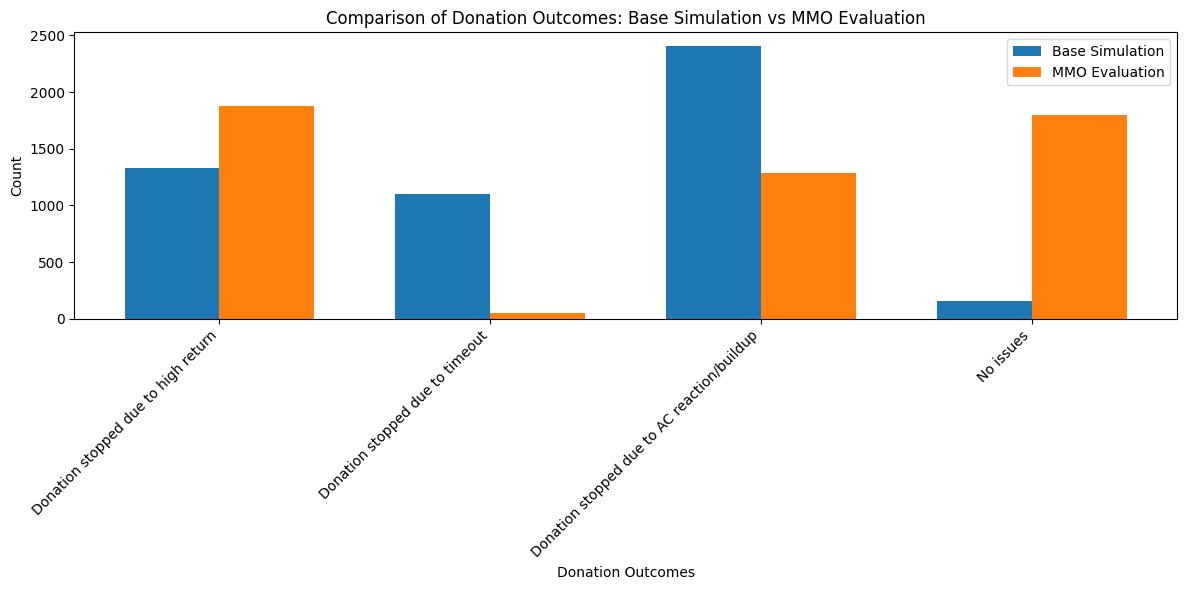

In [691]:
# Results comparison
base_outcome_dict = defauls_results['outcomes_df'][0]['outcome'].value_counts().to_dict()
mmo_outcome_dict = mmo_results['outcomes_df'][0]['outcome'].value_counts().to_dict()
labels = list(set(base_outcome_dict.keys()).union(set(mmo_outcome_dict.keys())))
base_values = [base_outcome_dict.get(label, 0) for label in labels]
mmo_values = [mmo_outcome_dict.get(label, 0) for label in labels]
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, base_values, width, label='Base Simulation')
rects2 = ax.bar(x + width/2, mmo_values, width, label='MMO Evaluation')
ax.set_xlabel('Donation Outcomes')
ax.set_ylabel('Count')
ax.set_title('Comparison of Donation Outcomes: Base Simulation vs MMO Evaluation')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## Accuracy study

In [2]:
base_tot_time = base_sim['donationElapsedTime'].sum()
mmo_tot_time = mmo_sim['donationElapsedTime'].sum()

return_mmo_IDs = mmo_outcome['donor_ID'].where(mmo_outcome['outcome'] == 'Donation stopped due to high return').dropna().count()
return_base_IDs = base_outcome['donor_ID'].where(base_outcome['outcome'] == 'Donation stopped due to high return').dropna().count()

base_score = (return_base_IDs / base_tot_time) * 10000
mmo_score = (return_mmo_IDs / mmo_tot_time) * 10000

print(f'Incident density per 10,000 minutes\n\nClass: Donation stopped due to high return\n\nBase simulation: {base_score:.4f}\nMMO simulation: {mmo_score:.4f}')

Incident density per 10,000 minutes

Class: Donation stopped due to high return

Base simulation: 8.8017
MMO simulation: 4.5877


In [3]:
AC_mmo_IDs = mmo_outcome['donor_ID'].where(mmo_outcome['outcome'] == 'Donation stopped due to AC reaction/buildup').dropna().count()
AC_base_IDs = base_outcome['donor_ID'].where(base_outcome['outcome'] == 'Donation stopped due to AC reaction/buildup').dropna().count()

base_score = (AC_base_IDs / base_tot_time) * 10000
mmo_score = (AC_mmo_IDs / mmo_tot_time) * 10000

print(f'Incident density per 10,000 minutes\n\nClass: Donation stopped due to AC reaction/buildup\n\nBase simulation: {base_score:.4f}\nMMO simulation: {mmo_score:.4f}')

Incident density per 10,000 minutes

Class: Donation stopped due to AC reaction/buildup

Base simulation: 16.5310
MMO simulation: 3.2886


In [4]:
draw_mmo_IDs = mmo_outcome['donor_ID'].where(mmo_outcome['outcome'] == 'Donation stopped due to timeout').dropna().count()
draw_base_IDs = base_outcome['donor_ID'].where(base_outcome['outcome'] == 'Donation stopped due to timeout').dropna().count()

base_score = (draw_base_IDs / base_tot_time) * 10000
mmo_score = (draw_mmo_IDs / mmo_tot_time) * 10000

print(f'Incident density per 10,000 minutes\n\nClass: Donation stopped due to timeout\n\nBase simulation: {base_score:.4f}\nMMO simulation: {mmo_score:.4f}')

Incident density per 10,000 minutes

Class: Donation stopped due to timeout

Base simulation: 7.7283
MMO simulation: 0.1293


In [5]:
reg_mmo_IDs = mmo_outcome['donor_ID'].where(mmo_outcome['outcome'] == 'No issues').dropna().count()
reg_base_IDs = base_outcome['donor_ID'].where(base_outcome['outcome'] == 'No issues').dropna().count()

base_score = (reg_base_IDs / base_tot_time) * 10000
mmo_score = (reg_mmo_IDs / mmo_tot_time) * 10000

print(f'Incident density per 10,000 minutes\n\nClass: No issues\n\nBase simulation: {base_score:.4f}\nMMO simulation: {mmo_score:.4f}')

Incident density per 10,000 minutes

Class: No issues

Base simulation: 1.0475
MMO simulation: 4.4004


In [707]:
classes = [
    'Request first needle adjustment',
    'Request second needle adjustment',
    'Lower return speed from terminal',
    'Pause machine for 1 minute and inform nurse',
    'Inform nurse and lower AC concentration',
    'End donation, AC toxicity reached/buildup',
    'No action'
]

tps = []
fns = []
fps = []

# Generate true positive list
for cl in classes:
    tps.append(int(mmo_sim['donorID'].where((mmo_sim['label'] == mmo_sim['predLabel']) & (mmo_sim['predLabel'] == cl)).dropna().count()))
    fns.append(int(mmo_sim['donorID'].where((mmo_sim['label'] != mmo_sim['predLabel']) & (mmo_sim['label'] == cl)).dropna().count()))
    fps.append(int(mmo_sim['donorID'].where((mmo_sim['label'] != mmo_sim['predLabel']) & (mmo_sim['predLabel'] == cl)).dropna().count()))

tps, fns, fps


([75578, 42764, 202769, 67614, 49585, 26512, 2581619],
 [1174, 805, 14349, 0, 0, 0, 19805],
 [130, 129, 21144, 0, 0, 0, 14730])

In [712]:
def test_calculator(tp, fn, fp, classes):
    df = {
        'Classes': classes,
        'Sensitivity': [],
        'Precision': [],
        'F1-score': [],
    }

    for idx in range(len(classes)):
        # Calculations
        sens = tp[idx]/(tp[idx] + fn[idx])
        prec = tp[idx]/(tp[idx] + fp[idx])
        f1 = (2 * prec * sens)/(prec + sens)


        df['Sensitivity'].append(sens)
        df['Precision'].append(prec)
        df['F1-score'].append(f1)
        # print(f'{cl}: sensitivity = {sens}\n')
    return pd.DataFrame(df)


test_df = test_calculator(tps, fns, fps, classes)
test_df

,Classes,Sensitivity,Precision,F1-score
0,Request first needle adjustment,0.984704,0.998283,0.991447
1,Request second needle adjustment,0.981524,0.996993,0.989198
2,Lower return speed from terminal,0.933912,0.905570,0.919523
3,Pause machine for 1 minute and inform nurse,1.000000,1.000000,1.000000
4,Inform nurse and lower AC concentration,1.000000,1.000000,1.000000
5,"End donation, AC toxicity reached/buildup",1.000000,1.000000,1.000000
6,No action,0.992387,0.994327,0.993356


In [6]:
macro_f1 = float(test_df['F1-score'].sum())/len(test_df)

print(f'Macro F1-score: {macro_f1:.4f}')

Macro F1-score: 0.9848
